In [27]:
import pandas as pd
import numpy as np
import xarray as xr
from pathlib import Path
import xugrid

#   Some station names are just numbers. No worries with the DtypeWarning - should get read in as a string.
cmar_path = Path(r"C:\Users\Syed Haque\Documents\GitHub\ohw26_model_downsampling\data\cmar_weekly_average_temperature.csv")
cmar = pd.read_csv(cmar_path)


full_path = Path(r"C:\Users\Syed Haque\Documents\GitHub\ohw26_model_downsampling\data\stmb_fvcom_weekly_avg_temp.nc")
minifv = xr.open_dataset(full_path, decode_times=False)
minifv0 = minifv[['temp','nv','h']].isel(time=0, siglay=0)

In [16]:
cmar.head()

,station,sensor_height_above_seafloor_m,iso_year,iso_week,mean_temperature,n
0,1012,20.0,2016,3,3.369276,152
1,1012,20.0,2016,4,3.045893,336
2,1012,20.0,2016,5,3.159143,336
3,1012,20.0,2016,6,3.141702,336
4,1012,20.0,2016,7,2.574333,336


In [17]:
cmar.describe()

,sensor_height_above_seafloor_m,iso_year,iso_week,mean_temperature,n
count,4163.000000,4163.000000,4163.000000,4163.000000,4163.000000
mean,15.698607,2021.491953,25.785491,8.423414,1601.248138
std,10.944047,2.055599,15.715067,4.325933,2665.946829
min,0.000000,2016.000000,1.000000,-1.117758,10.000000
25%,6.000000,2020.000000,12.000000,4.674468,1336.000000
50%,15.000000,2021.000000,23.000000,7.786963,1344.000000
75%,24.000000,2023.000000,41.000000,12.668615,1344.000000
max,42.000000,2025.000000,53.000000,19.335114,20168.000000


In [18]:
minifv

<xarray.Dataset> Size: 177MB
Dimensions:        (time: 53, nele: 7697, node: 4247, siglay: 20, siglev: 21,
                    three: 3, maxnode: 10, maxelem: 8, four: 4)
Coordinates:
  * time           (time) int64 424B 0 7 14 21 28 35 ... 329 336 343 350 357 364
    lonc           (nele) float32 31kB ...
    latc           (nele) float32 31kB ...
    lon            (node) float32 17kB ...
    lat            (node) float32 17kB ...
    siglay         (siglay, node) float32 340kB ...
    siglev         (siglev, node) float32 357kB ...
Dimensions without coordinates: nele, node, three, maxnode, maxelem, four
Data variables: (12/27)
    nprocs         (time) float64 424B ...
    partition      (time, nele) int32 2MB ...
    x              (time, node) float32 900kB ...
    y              (time, node) float32 900kB ...
    xc             (time, nele) float32 2MB ...
    yc             (time, nele) float32 2MB ...
    ...             ...
    awx            (time, three, nele) float32 5MB ...
    awy            (time, three, nele) float32 5MB ...
    art2           (time, node) float32 900kB ...
    art1           (time, node) float32 900kB ...
    omega          (time, siglev, node) float32 19MB ...
    temp           (time, siglay, node) float32 18MB ...

In [19]:
minifv['temp']

<xarray.DataArray 'temp' (time: 53, siglay: 20, node: 4247)> Size: 18MB
[4501820 values with dtype=float32]
Coordinates:
  * time     (time) int64 424B 0 7 14 21 28 35 42 ... 329 336 343 350 357 364
    siglay   (siglay, node) float32 340kB ...
    lon      (node) float32 17kB ...
    lat      (node) float32 17kB ...
Dimensions without coordinates: node
Attributes:
    long_name:      temperature
    standard_name:  sea_water_temperature
    units:          degrees_C
    grid:           fvcom_grid
    type:           data
    mesh:           fvcom_mesh
    location:       node

In [23]:
minifv_uds = xugrid.UgridDataset(minifv)

In [30]:
# minifv_uds['temp'].isel(time=0, siglay=0).ugrid.plot()


In [31]:
import xugrid as xu

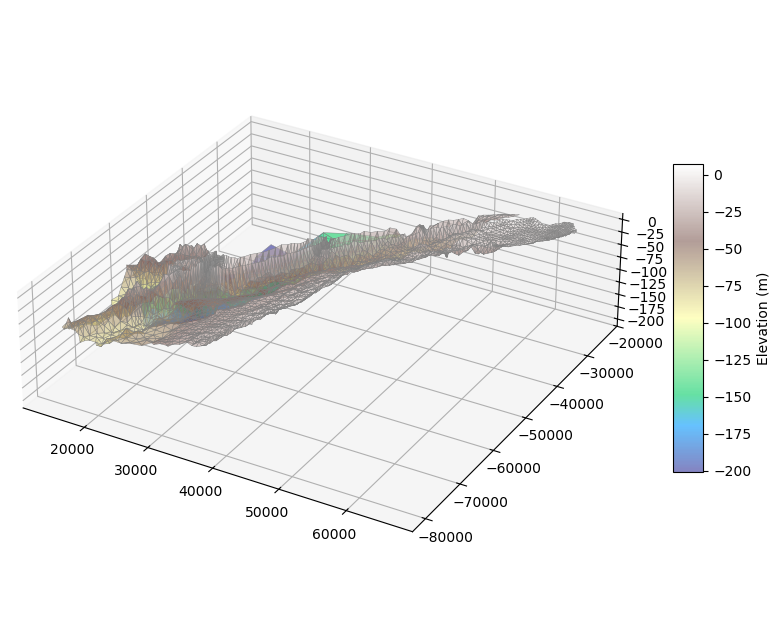

In [56]:
import matplotlib.pyplot as plt
import matplotlib.tri as tri

# 1. Drop the time dimension upfront using xarray
ds = minifv.isel(time=0) if "time" in minifv.dims else minifv

# 2. Extract 1D spatial coordinates and bathymetry
x = ds["x"].values
y = ds["y"].values
z = -ds["h"].values

# 3. Format connectivity matrix (3, nelem) -> (nelem, 3) with 0-based indexing
faces = ds["nv"].values.T - 1

# 4. Build Triangulation
triangulation = tri.Triangulation(x, y, triangles=faces)

# 5. Render 3D surface
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_trisurf(
    triangulation,
    z,
    cmap="terrain",
    edgecolor="gray",
    linewidth=0.3,
    alpha=0.6,
)

ax.set_zlabel("Depth (m)")
ax.set_box_aspect((1, 1, 0.3))
fig.colorbar(surf, ax=ax, label="Elevation (m)", shrink=0.5, aspect=10)

plt.show()

In [39]:
print(minifv["x"].dims)
print(minifv["x"].shape)

('time', 'node')
(53, 4247)


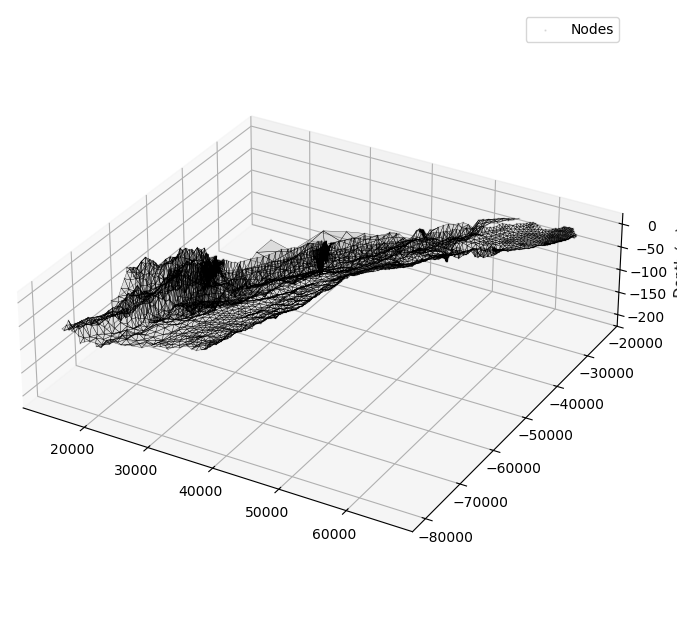

In [47]:
import matplotlib.pyplot as plt
import matplotlib.tri as tri

# 1. Drop time dimension
ds = minifv.isel(time=0) if "time" in minifv.dims else minifv

# 2. Extract 1D spatial coordinates and bathymetry depth
x = ds["x"].values
y = ds["y"].values
z = -ds["h"].values

# 3. Connectivity matrix: (3, nelem) -> (nelem, 3) 0-based
faces = ds["nv"].values.T - 1

# 4. Build Triangulation
triangulation = tri.Triangulation(x, y, triangles=faces)

# 5. Render 3D Grid & Nodes
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

# Wireframe mesh (transparent faces, visible edges)
ax.plot_trisurf(
    triangulation,
    z,
    color="none",        # Removes surface color fill
    edgecolor="black",   # Grid lines
    linewidth=0.2,
    alpha=0.1
)

# Plot nodes as points
ax.scatter(x, y, z, color="black",alpha=0.1, s=0.5, label="Nodes")

# Styling
ax.set_zlabel("Depth (m)")
ax.set_box_aspect((1, 1, 0.3))
ax.legend(loc="upper right")

plt.show()

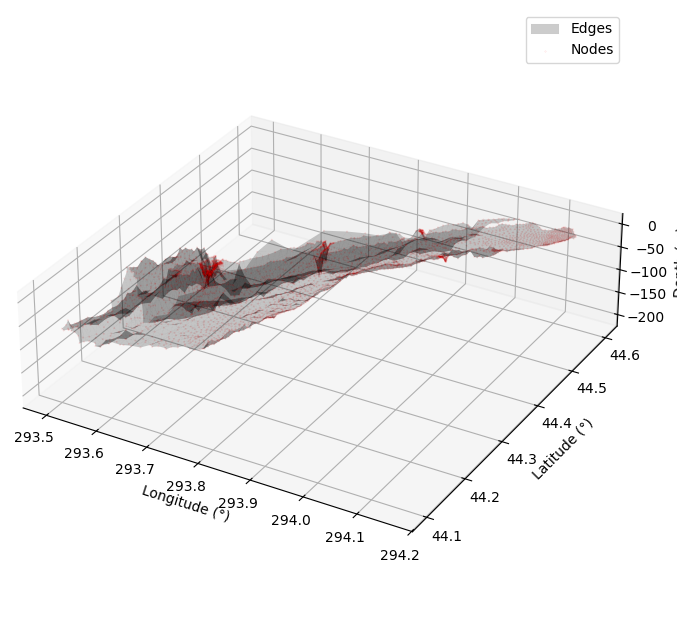

In [55]:
import matplotlib.pyplot as plt
import matplotlib.tri as tri

# 1. Drop time dimension
ds = minifv.isel(time=0) if "time" in minifv.dims else minifv

# 2. Extract geographic coordinates and bathymetry depth
lon = ds["lon"].values
lat = ds["lat"].values
z = -ds["h"].values

# 3. Connectivity matrix: (3, nelem) -> (nelem, 3) 0-based
faces = ds["nv"].values.T - 1

# 4. Build Triangulation using geographic coordinates
triangulation = tri.Triangulation(lon, lat, triangles=faces)

# 5. Render 3D Wireframe Mesh & Nodes
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

# Wireframe grid
ax.plot_trisurf(
    triangulation,
    z,
    color="none",
    edgecolor="black",
    linewidth=0.004,
    alpha=0.2,
    label='Edges'
)

# Node positions
ax.scatter(lon, lat, z, color="red", s=0.05,alpha=0.2, label="Nodes")

# Styling
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.set_zlabel("Depth (m)")
ax.set_box_aspect((1, 1, 0.3))
ax.legend(loc="upper right")

plt.show()

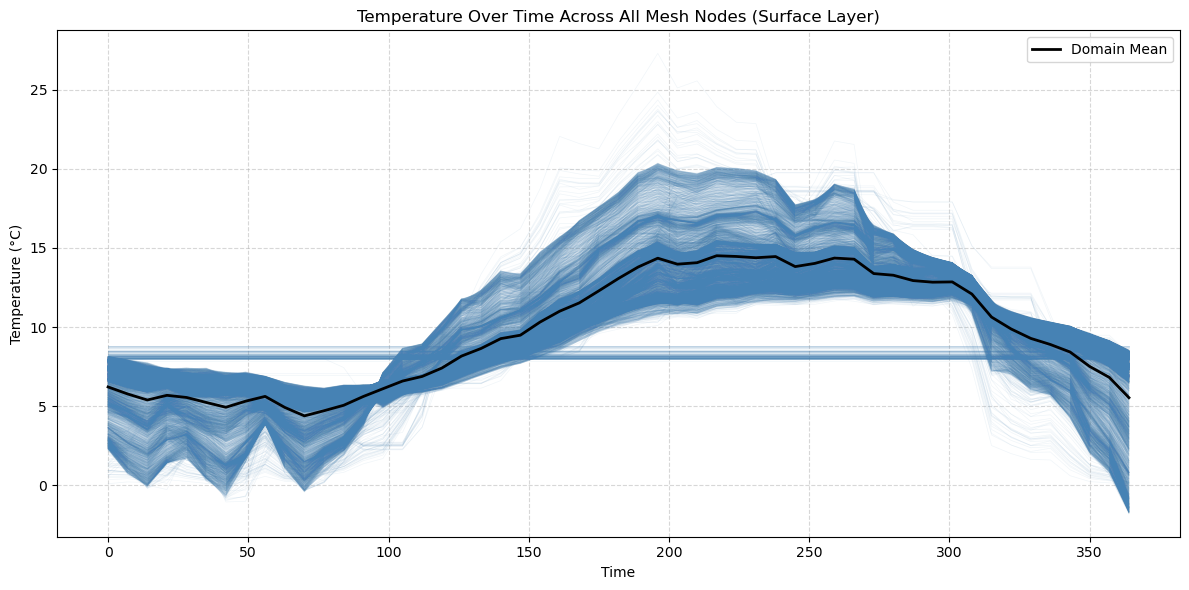

In [57]:
import matplotlib.pyplot as plt

# 1. Extract surface temperature for all time steps across all nodes
# Shape: (time, node)
temp_surface = minifv["temp"].isel(siglay=0)

# 2. Extract time array
time = minifv["time"].values

fig, ax = plt.subplots(figsize=(12, 6))

# 3. Plot all node time-series using a low alpha to manage visual clutter
# Passing 2D array (time, node) renders all node lines simultaneously
ax.plot(time, temp_surface.values, color="steelblue", alpha=0.08, linewidth=0.5)

# 4. Overlay the domain-average temperature line for reference
ax.plot(
    time,
    temp_surface.mean(dim="node").values,
    color="black",
    linewidth=2,
    label="Domain Mean",
)

# Styling
ax.set_xlabel("Time")
ax.set_ylabel("Temperature (°C)")
ax.set_title("Temperature Over Time Across All Mesh Nodes (Surface Layer)")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

C:\Users\Syed Haque\AppData\Local\Temp\ipykernel_28180\4092007586.py:8: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  range(minifv.dims["node"]),


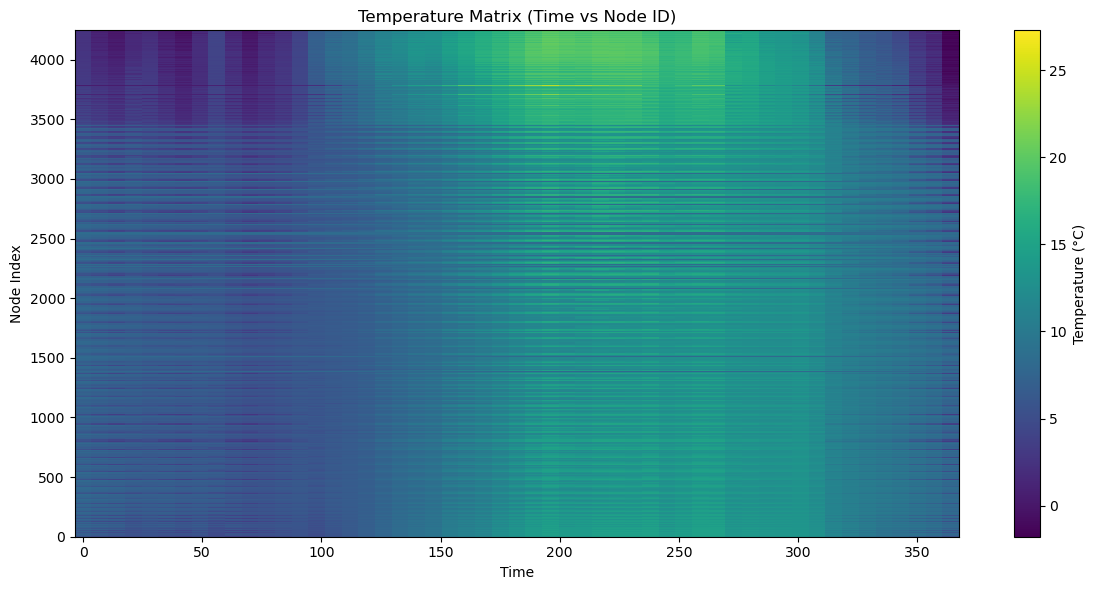

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plot Time vs Node matrix
plt.pcolormesh(
    minifv["time"].values,
    range(minifv.dims["node"]),
    minifv["temp"].isel(siglay=0).T.values,  # Transpose to (node, time)
    cmap="viridis",
    shading="nearest",
)

plt.colorbar(label="Temperature (°C)")
plt.xlabel("Time")
plt.ylabel("Node Index")
plt.title("Temperature Matrix (Time vs Node ID)")
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

# 1. Extract dimensions
time = minifv["time"].values
temp = minifv["temp"]  # Shape: (time, siglay, node)
num_layers = temp.sizes["siglay"]

# 2. Set up colormap across sigma layers
cmap = plt.cm.viridis
norm = mcolors.Normalize(vmin=0, vmax=num_layers - 1)

fig, ax = plt.subplots(figsize=(12, 6))

# 3. Plot each layer's nodes (low alpha prevents heavy overplotting)
for k in range(num_layers):
    layer_temp = temp.isel(siglay=k).values  # Shape: (time, node)
    color = cmap(norm(k))

    # Passing 2D array (time, node) plots all nodes for layer k in one call
    ax.plot(time, layer_temp, color=color, alpha=0.03, linewidth=0.4)

# 4. Optional: Overlay layer mean lines with solid colors for clarity
for k in range(0, num_layers, max(1, num_layers // 5)):  # Sample 5 layers
    mean_temp = temp.isel(siglay=k).mean(dim="node").values
    ax.plot(time, mean_temp, color=cmap(norm(k)), linewidth=2)

# 5. Add colorbar for Sigma Layers
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Sigma Layer Index (0 = Surface)")

# Styling
ax.set_xlabel("Time")
ax.set_ylabel("Temperature (°C)")
ax.set_title("Node Temperatures Over Time Colored by Sigma Layer")
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()